# Figure 4: Fold-wise Dice Score Boxplots

Fold-wise distribution of test Dice scores across SegFormer, Mask R-CNN, and YOLOv8-Seg.

In [1]:
# Imports
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import glob
from scipy import stats
from scipy.stats import wilcoxon, ttest_rel, mannwhitneyu
from sklearn.metrics import (confusion_matrix, roc_curve, precision_recall_curve, auc, 
                              brier_score_loss, accuracy_score, f1_score, recall_score, 
                              precision_score, cohen_kappa_score)
from sklearn.calibration import calibration_curve
from sklearn.utils import resample
import warnings
warnings.filterwarnings('ignore')

# Plotting setup
sns.set_style('whitegrid')
sns.set_context('paper', font_scale=1.2)
plt.rcParams.update({
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial']
})

# Paths
OUTPUT_BASE = 'folds/folds/output'
FIG_DIR = 'q1_publication_results'
os.makedirs(FIG_DIR, exist_ok=True)
for subdir in ['figures', 'tables', 'supplementary']:
    os.makedirs(os.path.join(FIG_DIR, subdir), exist_ok=True)

print("✓ Setup complete!")

✓ Setup complete!


In [2]:
# Load summary
summary_df = pd.read_csv(os.path.join(OUTPUT_BASE, 'all_folds_runs_summary.csv'))
print(f"Total runs: {len(summary_df)}")
print(f"Unique folds: {summary_df['fold'].nunique()}")
print(f"Runs per fold: {summary_df.groupby('fold').size().tolist()}")

summary_df.head()

Total runs: 50
Unique folds: 5
Runs per fold: [10, 10, 10, 10, 10]


,best_arthrit_boost,best_cls_loss_weight,best_control_boost,best_eval_batch_size,best_focal_gamma,best_lr,best_train_batch_size,best_weight_decay,final_test_loss,final_test_mDice_fg_patient,...,lr_scheduler_type,max_grad_norm,patient_balanced_sampling,pool_alpha,pool_mode,run_idx,search_mean_val_mDice_fg_patient,seed,train_runtime,unfreeze_epoch
0,1.847107,0.256966,2.766209,4,NaN,0.000054,1,0.009842,0.977758,0.827919,...,cosine,1.0,True,1.0,mask,1,0.821892,42,2058.2716,5
1,1.847107,0.256966,2.766209,4,NaN,0.000054,1,0.009842,0.540005,0.823755,...,cosine,1.0,True,1.0,mask,2,0.821892,1042,1128.9786,5
2,1.847107,0.256966,2.766209,4,NaN,0.000054,1,0.009842,0.628001,0.812692,...,cosine,1.0,True,1.0,mask,3,0.821892,2042,1581.7083,5
3,1.847107,0.256966,2.766209,4,NaN,0.000054,1,0.009842,0.315959,0.773808,...,cosine,1.0,True,1.0,mask,4,0.821892,3042,444.4284,5
4,1.847107,0.256966,2.766209,4,NaN,0.000054,1,0.009842,0.957584,0.833754,...,cosine,1.0,True,1.0,mask,5,0.821892,4042,2646.8509,5


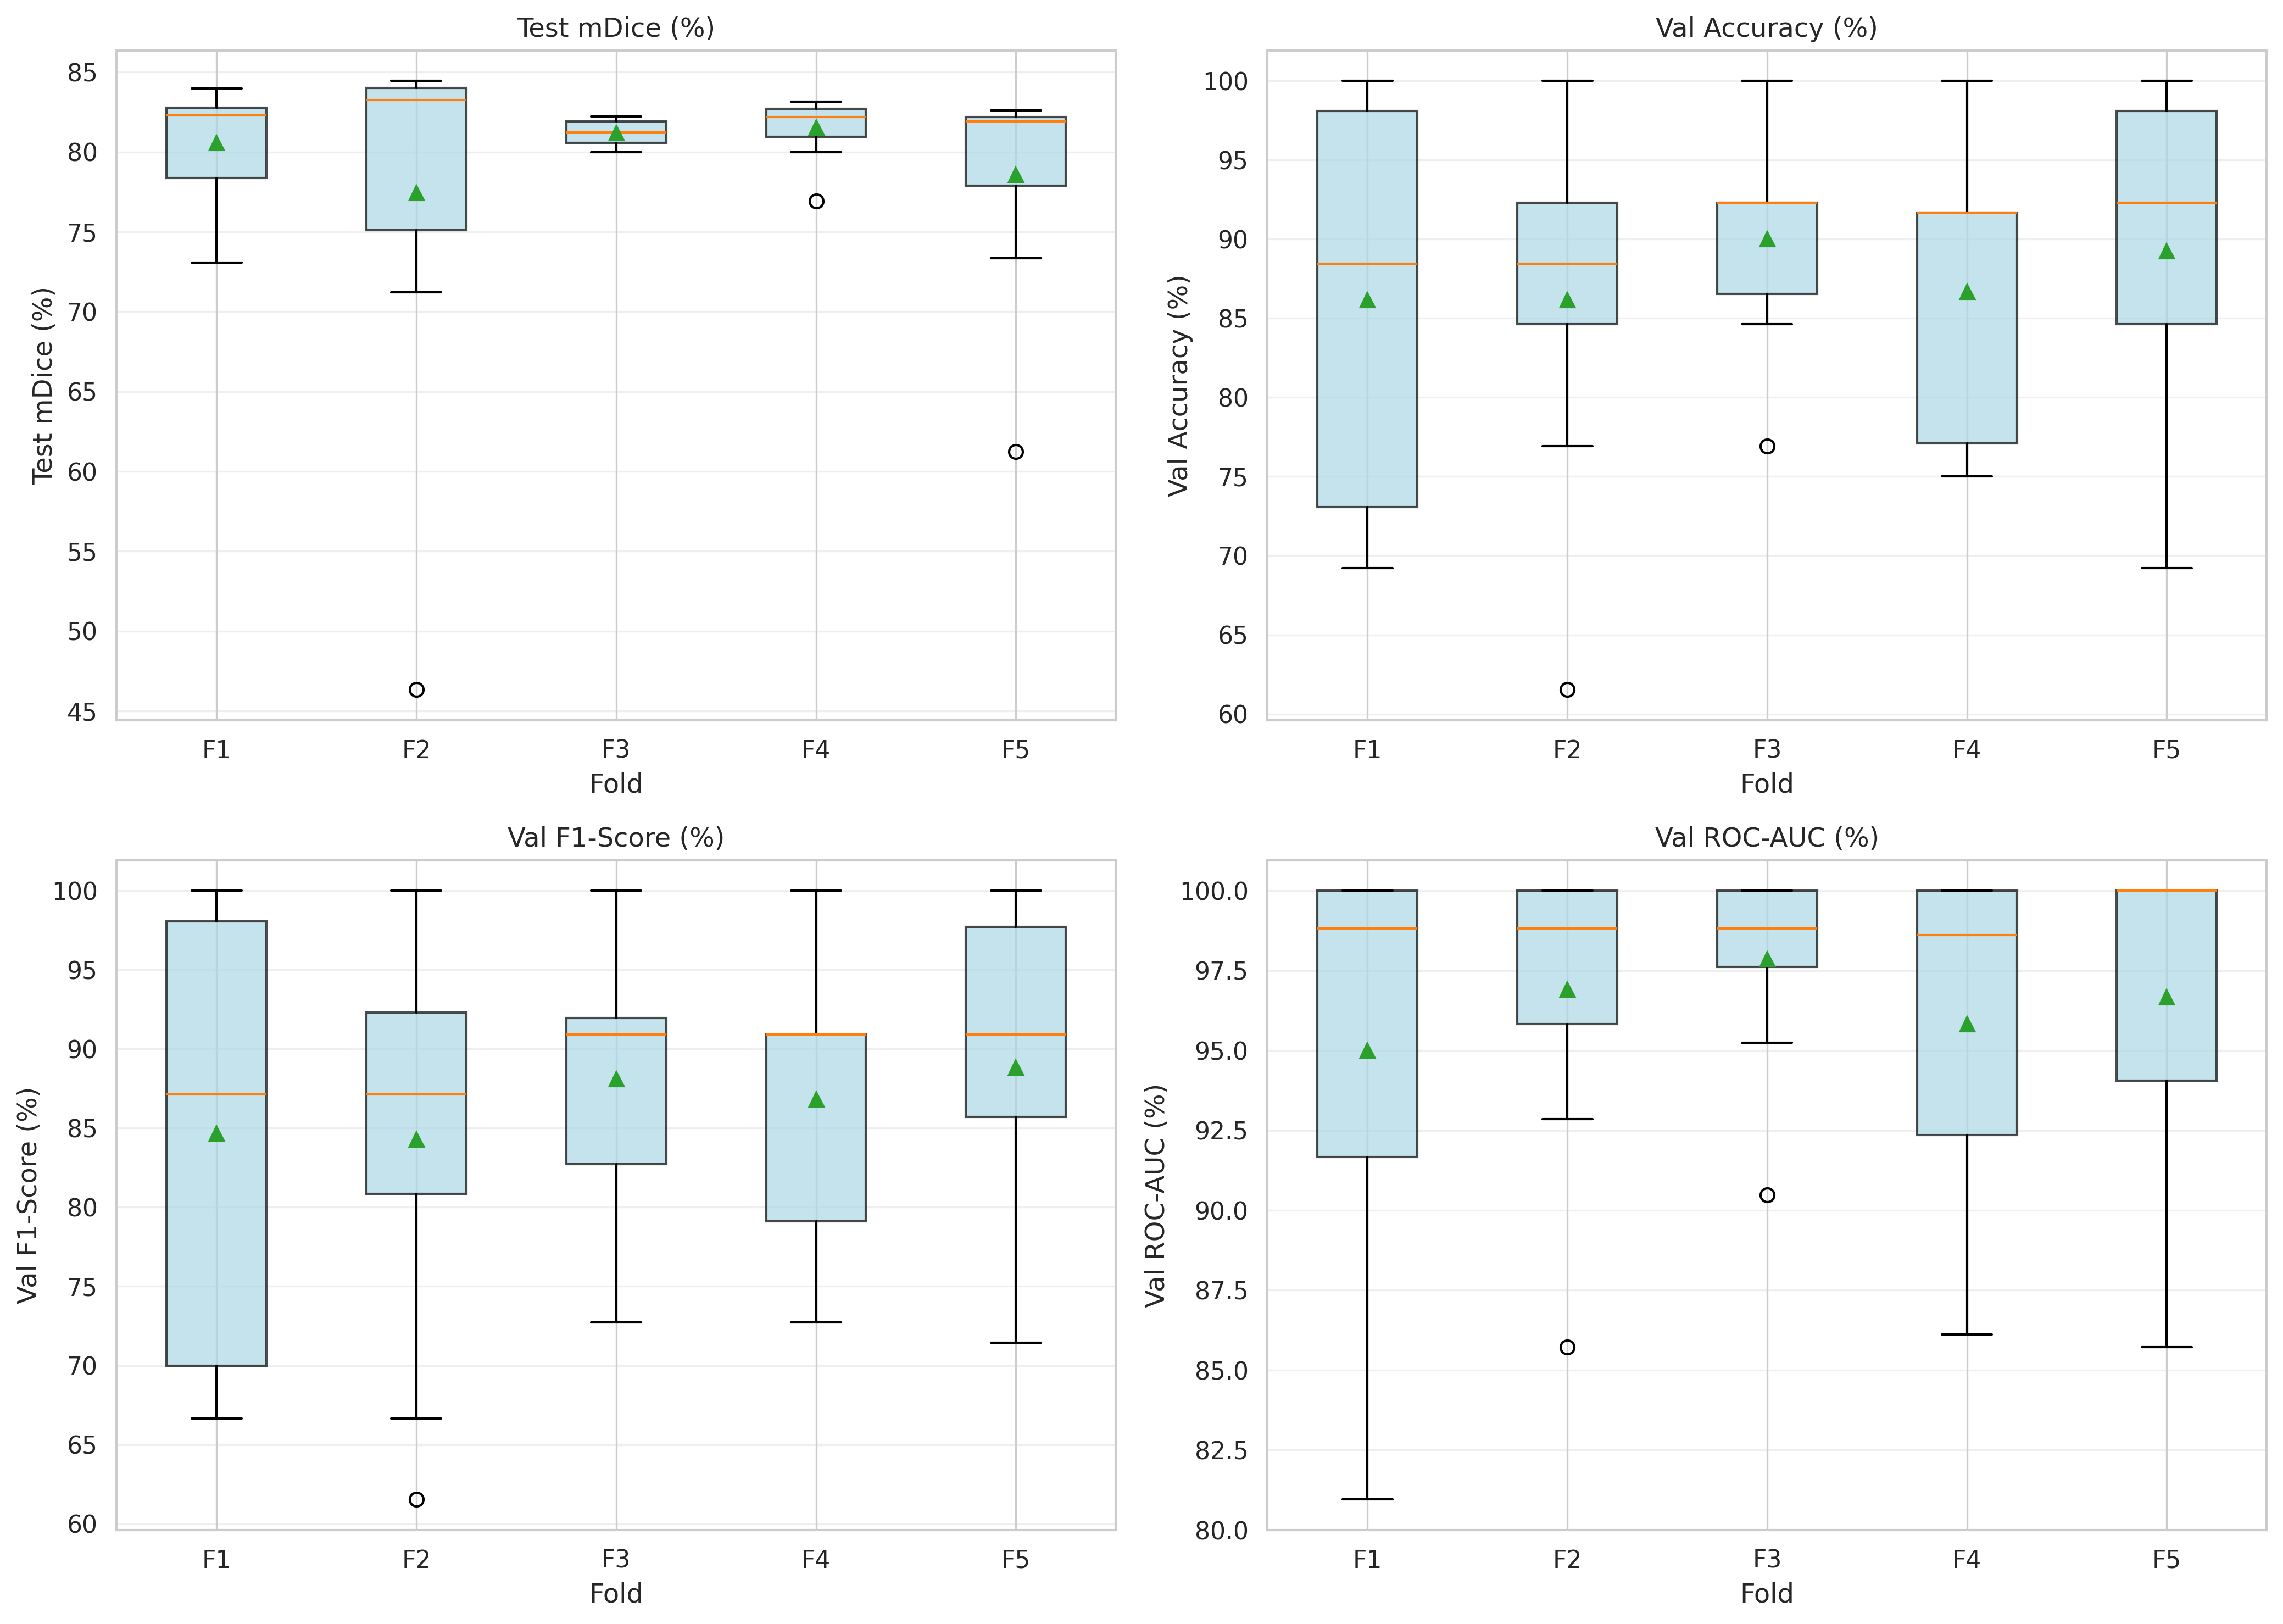

In [7]:
# Box plots per fold
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics_to_plot = [
    ('final_test_mDice_fg_patient', 'Test mDice (%)'),
    ('final_val_cls_acc_patient', 'Val Accuracy (%)'),
    ('final_val_cls_f1_patient', 'Val F1-Score (%)'),
    ('final_val_cls_roc_auc_patient', 'Val ROC-AUC (%)')
]

for ax, (col, title) in zip(axes.flat, metrics_to_plot):
    data = []
    labels = []
    for fold in sorted(summary_df['fold'].unique()):
        fold_data = summary_df[summary_df['fold'] == fold][col].dropna() * 100
        data.append(fold_data)
        labels.append(fold.replace('FOLD_', 'F'))
    
    bp = ax.boxplot(data, labels=labels, patch_artist=True, showmeans=True)
    for patch in bp['boxes']:
        patch.set_facecolor('lightblue')
        patch.set_alpha(0.7)
    
    ax.set_ylabel(title)
    ax.set_xlabel('Fold')
    ax.grid(axis='y', alpha=0.3)
    ax.set_title(title)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'figures/per_fold_boxplots.png'), dpi=300, bbox_inches='tight')
plt.show()